In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

In [2]:
career = pd.read_csv('career_ladder.csv')

print("Shape:", career.shape)
print("\nFirst 5 rows:")
print(career.head())

Shape: (1500, 16)

First 5 rows:
                   career_name         domain       paid  customer_type  \
0                  UX Designer      education  sometimes       platform   
1               Civil Engineer         design  sometimes  organizations   
2  Vehicle Armoring Specialist         design  sometimes       platform   
3         Marketing Specialist     non-profit  sometimes      companies   
4                      Teacher  entertainment         no    individuals   

  product_type physical_presence location_specific   scale people_interaction  \
0     physical               yes               yes   large             medium   
1   experience                no                no   small             medium   
2      content               yes               yes  medium               high   
3   experience                no                no   large             medium   
4     physical         sometimes               yes   small             medium   

  manual_work creative_output

In [3]:
print("\nColumn info:")
career.info()



Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   career_name         1500 non-null   object
 1   domain              1500 non-null   object
 2   paid                1500 non-null   object
 3   customer_type       1500 non-null   object
 4   product_type        1500 non-null   object
 5   physical_presence   1500 non-null   object
 6   location_specific   1500 non-null   object
 7   scale               1500 non-null   object
 8   people_interaction  1500 non-null   object
 9   manual_work         1500 non-null   object
 10  creative_output     1500 non-null   object
 11  technical_work      1500 non-null   object
 12  uniqueness_level    1500 non-null   object
 13  automation_risk     1500 non-null   object
 14  social_impact       1500 non-null   object
 15  typical_age_min     1500 non-null   int64 
dtypes: int64(1

In [4]:
numerical_cols = career.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_cols)

['typical_age_min']


In [5]:
categorical_cols = career.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['career_name', 'domain', 'paid', 'customer_type', 'product_type', 'physical_presence', 'location_specific', 'scale', 'people_interaction', 'manual_work', 'creative_output', 'technical_work', 'uniqueness_level', 'automation_risk', 'social_impact']


In [6]:
print(career.isnull().sum())

career_name           0
domain                0
paid                  0
customer_type         0
product_type          0
physical_presence     0
location_specific     0
scale                 0
people_interaction    0
manual_work           0
creative_output       0
technical_work        0
uniqueness_level      0
automation_risk       0
social_impact         0
typical_age_min       0
dtype: int64


In [7]:
print("\n--- career_name ---")
print(career['career_name'].value_counts())

print("\n--- creative_output ---")
print(career['creative_output'].value_counts())

print("\n--- technical_work ---")
print(career['technical_work'].value_counts())

print("\n--- uniqueness_level ---")
print(career['uniqueness_level'].value_counts())

print("\n--- automation_risk ---")
print(career['automation_risk'].value_counts())

print("\n--- social_impact ---")
print(career['social_impact'].value_counts())

print("\n--- manual_work ---")
print(career['manual_work'].value_counts())

print("\n--- people_interaction ---")
print(career['people_interaction'].value_counts())

print("\n--- scale ---")
print(career['scale'].value_counts())

print("\n--- location_specific ---")
print(career['location_specific'].value_counts())

print("\n--- physical_presence ---")
print(career['physical_presence'].value_counts())

print("\n--- product_type ---")
print(career['product_type'].value_counts())

print("\n--- customer_type ---")
print(career['customer_type'].value_counts())

print("\n--- paid ---")
print(career['paid'].value_counts())

print("\n--- domain ---")
print(career['domain'].value_counts())



--- career_name ---
career_name
Data Analyst                   60
Civil Engineer                 59
Journalist                     58
YouTuber                       57
Mechanical Technician          57
Software Developer             57
Video Editor                   56
Photographer                   56
Product Manager                54
Marketing Specialist           54
Church Choir Member            54
Graphic Designer               53
Social Media Influencer        53
Community Manager              52
Automotive Engineer            52
Podcast Host                   51
Film Editor                    51
UX Designer                    50
Fashion Model                  49
Music Producer                 47
NGO Worker                     47
Sound Engineer                 45
Interior Designer              45
Event Coordinator              44
Teacher                        43
Religious Youth Leader         43
Content Creator                41
Architect                      40
Game Designer  

In [8]:
y = career['career_name']
X = career.drop(columns=['career_name'])

In [9]:
print("Features (X) shape:", X.shape)
print("Target  (y) shape:", y.shape)
print("\nUnique career names:", y.nunique())
print("\nCareer name distribution:")
print(y.value_counts())

Features (X) shape: (1500, 15)
Target  (y) shape: (1500,)

Unique career names: 30

Career name distribution:
career_name
Data Analyst                   60
Civil Engineer                 59
Journalist                     58
YouTuber                       57
Mechanical Technician          57
Software Developer             57
Video Editor                   56
Photographer                   56
Product Manager                54
Marketing Specialist           54
Church Choir Member            54
Graphic Designer               53
Social Media Influencer        53
Community Manager              52
Automotive Engineer            52
Podcast Host                   51
Film Editor                    51
UX Designer                    50
Fashion Model                  49
Music Producer                 47
NGO Worker                     47
Sound Engineer                 45
Interior Designer              45
Event Coordinator              44
Teacher                        43
Religious Youth Leader      

In [10]:
def entropy(series):
    # Remove zeros to avoid log2(0) = -inf
    probs = series.value_counts(normalize=True)
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))

def gini_index(series):
    probs = series.value_counts(normalize=True)
    return float(1 - np.sum(probs ** 2))

def information_gain(df, feature, target):
    # Entropy of the full dataset before the split
    total_entropy = entropy(df[target])

    # Weighted entropy after splitting on this feature
    weighted_entropy = 0
    for value, subset in df.groupby(feature):
        weight = len(subset) / len(df)
        weighted_entropy += weight * entropy(subset[target])

    # IG = reduction in entropy after the split
    return round(total_entropy - weighted_entropy, 6)

In [11]:
H_career = entropy(career['career_name'])
G_career  = gini_index(career['career_name'])

In [12]:
print("DATASET PURITY BEFORE ANY SPLIT")
print("=" * 50)
print(f"Shannon Entropy : {H_career:.4f} bits")
print(f"Gini Index      : {G_career:.4f}")
print(f"Number of classes: {y.nunique()}")
print(f"Max possible entropy: {np.log2(y.nunique()):.4f} bits")

DATASET PURITY BEFORE ANY SPLIT
Shannon Entropy : 4.8937 bits
Gini Index      : 0.9661
Number of classes: 30
Max possible entropy: 4.9069 bits


In [13]:
features_for_ig = [
    'people_interaction',
    'creative_output',
    'physical_presence',
    'scale',
    'automation_risk',
    'social_impact',
    'domain',
    'technical_work',
    'manual_work',
    'paid',
]

In [14]:
ig_results = {}
for f in features_for_ig:
    ig_results[f] = information_gain(career, f, 'career_name')

ig_df = (
    pd.DataFrame.from_dict(ig_results, orient='index', columns=['Information_Gain'])
    .sort_values(by='Information_Gain', ascending=False)
)

In [15]:
print("\nInformation Gain per feature (sorted):")
print(ig_df.round(6).to_string())
print(f"\nBest feature for root node: '{ig_df.index[0]}' (IG = {ig_df.iloc[0,0]:.6f})")



Information Gain per feature (sorted):
                    Information_Gain
domain                      0.135580
scale                       0.047089
social_impact               0.032033
paid                        0.030294
people_interaction          0.029353
automation_risk             0.028293
physical_presence           0.024564
creative_output             0.019825
technical_work              0.011367
manual_work                 0.009085

Best feature for root node: 'domain' (IG = 0.135580)


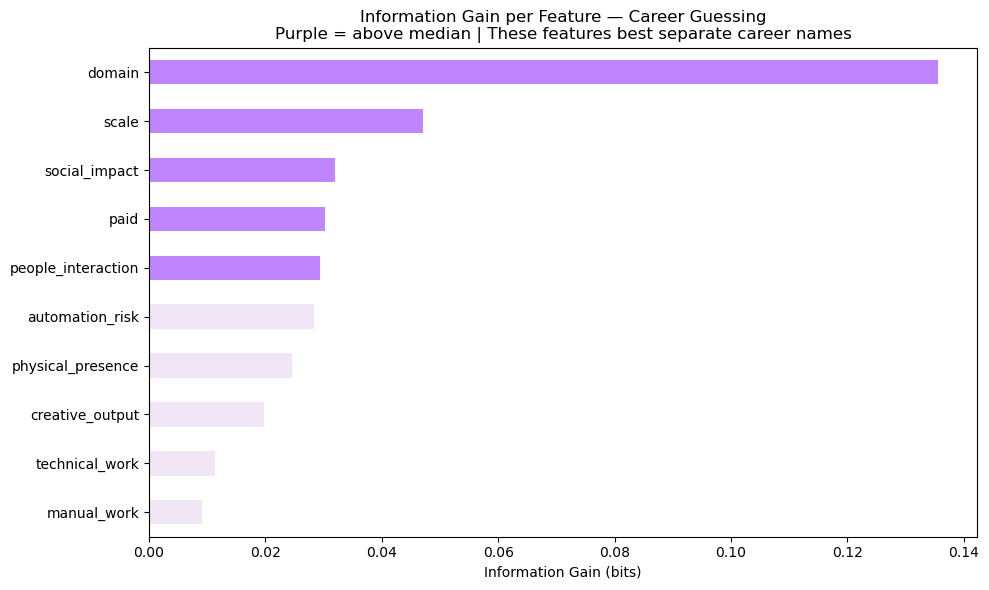

In [16]:
plt.figure(figsize=(10, 6))
colors = ['#C084FC' if ig > ig_df['Information_Gain'].median() else '#F0E6F6'
          for ig in ig_df['Information_Gain']]
ig_df['Information_Gain'].plot(kind='barh', color=colors)
plt.xlabel("Information Gain (bits)")
plt.title("Information Gain per Feature — Career Guessing\n"
          "Purple = above median | These features best separate career names")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("ig_career_guessing.png", dpi=150)
plt.show()

In [17]:
numerical_features = ['typical_age_min']

categorical_features = [
    'paid',
    'physical_presence',
    'location_specific',
    'manual_work',
    'creative_output',
    'technical_work',
    'people_interaction',
    'scale',
    'uniqueness_level',
    'automation_risk',
    'social_impact',
    'product_type',
    'customer_type',
    'domain'
]


In [18]:
category_orders = [
    ['no', 'sometimes', 'yes'],
    ['no', 'sometimes', 'yes'],
    ['no', 'yes'],
    ['no', 'yes'],
    ['no', 'yes'],
    ['no', 'yes'],
    ['low', 'medium', 'high'],
    ['small', 'medium', 'large', 'massive'],
    ['low', 'medium', 'high'],
    ['low', 'medium', 'high'],
    ['low', 'medium', 'high'],
    ['physical', 'digital', 'service', 'content', 'experience'],
    ['individuals', 'companies', 'organizations', 'brands', 'platform'],
    ['technology', 'music', 'automotive', 'religion', 'social media',
     'design', 'entertainment', 'marketing', 'education', 'non-profit']
]

In [19]:
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [20]:
categorical_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(
        categories=category_orders,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

In [21]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [23]:
print("Train set:", X_train.shape)
print("Test  set:", X_test.shape)


Train set: (1050, 15)
Test  set: (450, 15)


In [24]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

In [25]:
encoded_feature_names = numerical_features + categorical_features


In [26]:
X_train_enc_df = pd.DataFrame(
    X_train_enc,
    columns=encoded_feature_names,
    index=X_train.index
)


In [27]:
X_test_enc_df = pd.DataFrame(
    X_test_enc,
    columns=encoded_feature_names,
    index=X_test.index
)

In [28]:
X_test_enc_df = pd.DataFrame(
    X_test_enc,
    columns=encoded_feature_names,
    index=X_test.index
)

In [29]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_te, y_pred))

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    }



In [30]:
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=20,
        random_state=42
    ))
])

In [31]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [32]:
ab_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [33]:
print("BASELINE MODEL COMPARISON")
print("=" * 50)

results = []
results.append(evaluate_model(dt_model, X_train, X_test, y_train, y_test, "Decision Tree"))
results.append(evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest"))
results.append(evaluate_model(ab_model, X_train, X_test, y_train, y_test, "AdaBoost"))


BASELINE MODEL COMPARISON

===== Decision Tree =====
Accuracy : 0.0378
Precision: 0.0352
Recall   : 0.0378
F1 Score : 0.0355
Confusion Matrix:
[[0 1 0 0 0 2 1 0 1 0 0 0 0 0 0 2 1 1 0 0 0 0 0 1 0 0 1 0 0 1]
 [2 2 0 0 1 0 0 1 2 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 3]
 [1 0 0 2 0 0 1 1 0 1 0 0 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 2]
 [0 1 2 1 2 2 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 2 2 0 0 0 0 0 1 1]
 [0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 4 1 0 0 0 0 1 1 0 0 0 1 0 1 0]
 [0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 3 0 0 1 1]
 [0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 2 0 2 1 1 1 1 0 1 0 2 1]
 [0 1 0 1 0 1 1 1 0 0 1 0 0 2 0 1 0 0 0 0 0 1 0 2 0 0 0 0 0 1]
 [2 0 1 0 0 1 2 0 0 1 0 0 0 1 1 1 0 0 0 2 1 0 1 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 1 1 0 0 1 3 0 0 2 0 0 0 0 1 1 1 1 0 0 0 1 0 0 1]
 [0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 2]
 [0 0 0 1 0 1 1 1 2 1 2 0 0 0 0 0 3 0 1 0 0 0 1 0 0 2 0 0 0 0]
 [0 0 0 2 0 1 0 1 1 0 0 2 0 1 1 1 1 0 2 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 1 0 1 1 0 2 1 1 0 3 0 

In [34]:
results_df = pd.DataFrame(results)
print("\n\nSummary:")
print(results_df.to_string(index=False))



Summary:
        Model  Accuracy  Precision   Recall       F1
Decision Tree  0.037778   0.035158 0.037778 0.035529
Random Forest  0.035556   0.034513 0.035556 0.034020
     AdaBoost  0.037778   0.054029 0.037778 0.035257


In [35]:
print("\nStep 2-5: Evaluating KNN on test split...")

knn_eval = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_eval.fit(X_train_enc_df, y_train)



Step 2-5: Evaluating KNN on test split...


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [36]:
y_pred_knn = knn_eval.predict(X_test_enc_df)

In [37]:
knn_acc  = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_rec  = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_f1   = f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)

In [38]:
print(f"\n--- KNN Evaluation Results ---")
print(f"Accuracy : {knn_acc:.4f}")
print(f"Precision: {knn_prec:.4f}")
print(f"Recall   : {knn_rec:.4f}")
print(f"F1 Score : {knn_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))


--- KNN Evaluation Results ---
Accuracy : 0.0356
Precision: 0.0259
Recall   : 0.0356
F1 Score : 0.0275

Classification Report:
                             precision    recall  f1-score   support

                  Architect       0.00      0.00      0.00        12
        Automotive Engineer       0.04      0.12      0.06        16
        Church Choir Member       0.02      0.06      0.04        16
             Civil Engineer       0.05      0.11      0.06        18
          Community Manager       0.00      0.00      0.00        16
            Content Creator       0.10      0.25      0.14        12
               Data Analyst       0.03      0.06      0.04        18
          Event Coordinator       0.00      0.00      0.00        13
              Fashion Model       0.05      0.07      0.06        15
                Film Editor       0.06      0.07      0.06        15
              Game Designer       0.08      0.09      0.08        11
           Graphic Designer       0.06     

In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_cv_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=3, metric='euclidean'),
    X_train_enc_df, y_train,
    cv=cv,
    scoring='accuracy'
)


In [40]:
print(f"\nKNN — 5-Fold Cross-Validation:")
print(f"  Scores : {knn_cv_scores.round(4)}")
print(f"  Mean   : {knn_cv_scores.mean():.4f}")
print(f"  Std    : {knn_cv_scores.std():.4f}")


KNN — 5-Fold Cross-Validation:
  Scores : [0.0286 0.0333 0.0524 0.0571 0.0286]
  Mean   : 0.0400
  Std    : 0.0123


In [41]:
print("FINAL KNN — Refitting on ALL Data for Deployment")
print("=" * 50)

X_all     = career.drop(columns=['career_name'])
y_all     = career['career_name']


FINAL KNN — Refitting on ALL Data for Deployment


In [42]:
X_all_enc = preprocessor.fit_transform(X_all)

X_all_enc_df = pd.DataFrame(
    X_all_enc,
    columns=encoded_feature_names,
    index=career.index
)

In [43]:
knn_deploy = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_deploy.fit(X_all_enc_df, y_all)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [44]:
print(f"Deployment KNN fitted on {len(X_all_enc_df)} total career profiles")
print("This model is what gets saved and used in Flask.")

Deployment KNN fitted on 1500 total career profiles
This model is what gets saved and used in Flask.


In [45]:
all_results = pd.DataFrame({
    'Model':     ['Decision Tree', 'Random Forest', 'AdaBoost', 'KNN (k=3)'],
    'Accuracy':  [results[0]['Accuracy'], results[1]['Accuracy'], results[2]['Accuracy'], knn_acc],
    'Precision': [results[0]['Precision'], results[1]['Precision'], results[2]['Precision'], knn_prec],
    'Recall':    [results[0]['Recall'], results[1]['Recall'], results[2]['Recall'], knn_rec],
    'F1':        [results[0]['F1'], results[1]['F1'], results[2]['F1'], knn_f1],
}).round(4)

In [46]:
print("FULL MODEL COMPARISON — Career Guessing")
print("=" * 60)
print(all_results.to_string(index=False))

FULL MODEL COMPARISON — Career Guessing
        Model  Accuracy  Precision  Recall     F1
Decision Tree    0.0378     0.0352  0.0378 0.0355
Random Forest    0.0356     0.0345  0.0356 0.0340
     AdaBoost    0.0378     0.0540  0.0378 0.0353
    KNN (k=3)    0.0356     0.0259  0.0356 0.0275


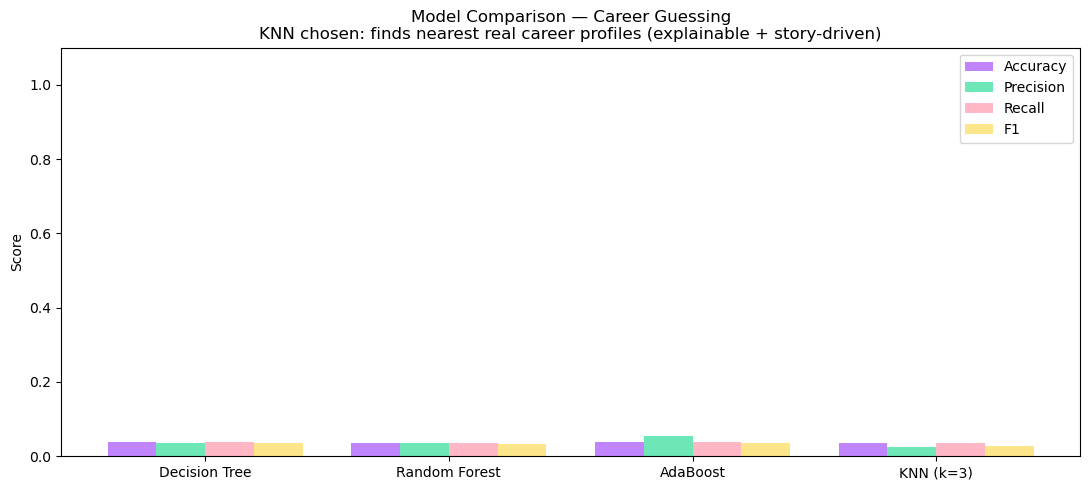

In [47]:
x = np.arange(4)
w = 0.2
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w*1.5, all_results['Accuracy'],  w, label='Accuracy',  color='#C084FC')
ax.bar(x - w*0.5, all_results['Precision'], w, label='Precision', color='#6EE7B7')
ax.bar(x + w*0.5, all_results['Recall'],    w, label='Recall',    color='#FFB7C5')
ax.bar(x + w*1.5, all_results['F1'],        w, label='F1',        color='#FDE68A')
ax.set_xticks(x)
ax.set_xticklabels(['Decision Tree', 'Random Forest', 'AdaBoost', 'KNN (k=3)'])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title('Model Comparison — Career Guessing\nKNN chosen: finds nearest real career profiles (explainable + story-driven)')
plt.tight_layout()


plt.show()

In [48]:
sample_answers = {
    'paid':               'yes',
    'physical_presence':  'yes',
    'location_specific':  'no',
    'manual_work':        'no',
    'creative_output':    'yes',
    'technical_work':     'no',
    'people_interaction': 'high',
    'scale':              'massive',
    'uniqueness_level':   'medium',
    'automation_risk':    'medium',
    'social_impact':      'high',
    'product_type':       'content',
    'customer_type':      'platform',
    'domain':             'social media',
    'typical_age_min':    21
}

In [49]:
sample_df      = pd.DataFrame([sample_answers])
sample_encoded = preprocessor.transform(sample_df)

In [50]:
predicted = knn_deploy.predict(sample_encoded)[0]
distances, indices = knn_deploy.kneighbors(sample_encoded)

In [51]:
print("Sanity check prediction:", predicted)
print("\n3 closest career profiles:")
print(career.iloc[indices[0]][['career_name']].to_string())

Sanity check prediction: Event Coordinator

3 closest career profiles:
             career_name
798           NGO Worker
597    Event Coordinator
1329  Software Developer


In [52]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(knn_deploy,   "models/guessing_knn.pkl")
joblib.dump(preprocessor, "models/guessing_preprocessor.pkl")
joblib.dump(career,       "models/career_df.pkl")

print("Saved: models/guessing_knn.pkl")
print("Saved: models/guessing_preprocessor.pkl")
print("Saved: models/career_df.pkl")
print("\nAll three files needed for Flask app.")

Saved: models/guessing_knn.pkl
Saved: models/guessing_preprocessor.pkl
Saved: models/career_df.pkl

All three files needed for Flask app.


In [53]:
print("  Career Guessing — Interactive Quiz")
print("  Inspired by Max Klymenko's Career Ladder")
print("=" * 50)
print("Answer each question with one of the options shown.")
print()

paid               = input("1.  Do you get paid for this work?                  (yes / no / sometimes): ")
physical_presence  = input("2.  Do you need to be physically present?           (yes / no / sometimes): ")
location_specific  = input("3.  Is the job tied to one specific location?       (yes / no): ")
manual_work        = input("4.  Does the job involve physical/manual work?      (yes / no): ")
creative_output    = input("5.  Is the work primarily creative?                 (yes / no): ")
technical_work     = input("6.  Is the work technical (code/machines/systems)?  (yes / no): ")
people_interaction = input("7.  How much do you work with people?               (low / medium / high): ")
scale              = input("8.  How large is the scale or reach of your work?  (small / medium / large / massive): ")
uniqueness_level   = input("9.  How niche or unique is the job?                 (low / medium / high): ")
automation_risk    = input("10. Can AI easily replace this job?                 (low / medium / high): ")
social_impact      = input("11. Does the job directly help people?              (low / medium / high): ")
product_type       = input("12. What do people receive from your work?          (physical / digital / service / content / experience): ")
customer_type      = input("13. Who primarily benefits from your work?          (individuals / companies / organizations / brands / platform): ")
domain             = input("14. Which domain best describes your work?          (technology / music / automotive / religion / social media / design / entertainment / marketing / education / non-profit): ")
typical_age_min    = int(input("15. At roughly what age do people start this career? (e.g. 18, 21, 25, 30): "))


  Career Guessing — Interactive Quiz
  Inspired by Max Klymenko's Career Ladder
Answer each question with one of the options shown.



ValueError: invalid literal for int() with base 10: ''

In [ ]:
user_df = pd.DataFrame([{
    'paid':               paid,
    'physical_presence':  physical_presence,
    'location_specific':  location_specific,
    'manual_work':        manual_work,
    'creative_output':    creative_output,
    'technical_work':     technical_work,
    'people_interaction': people_interaction,
    'scale':              scale,
    'uniqueness_level':   uniqueness_level,
    'automation_risk':    automation_risk,
    'social_impact':      social_impact,
    'product_type':       product_type,
    'customer_type':      customer_type,
    'domain':             domain,
    'typical_age_min':    typical_age_min
}])


In [ ]:
user_df = user_df[X.columns.tolist()]

In [ ]:
user_encoded = preprocessor.transform(user_df)

# KNN finds 3 nearest career profiles by Euclidean distance
predicted_career       = knn_deploy.predict(user_encoded)[0]
distances, indices     = knn_deploy.kneighbors(user_encoded)
closest_careers        = career.iloc[indices[0]]['career_name'].tolist()


In [ ]:
print("  Career Guess Result")
print("=" * 50)
print(f"\n🎯 Predicted Career: {predicted_career}")
print(f"\n3 closest career matches:")
for i, (career_name, dist) in enumerate(zip(closest_careers, distances[0]), 1):
    print(f"  {i}. {career_name}  (distance = {dist:.4f})")

  Career Guess Result

🎯 Predicted Career: Marketing Specialist

3 closest career matches:
  1. Sound Engineer  (distance = 2.0090)
  2. Podcast Host  (distance = 2.4788)
  3. Marketing Specialist  (distance = 2.9610)


: 